# 🛰️ Wildfire Classification using Satellite Images & CNN

Wildfires pose a significant threat to our environment and communities. The goal of this project is to build an automated tool that can help in early detection. We'll develop a **Convolutional Neural Network (CNN)**, a type of deep learning model, to accurately identify wildfires from satellite images.

---

## The Dataset 🏞️

For this task, we're using a specialized dataset from **Kaggle**. It contains thousands of satellite images, each neatly categorized into two classes: `wildfire` or `no_wildfire`.

To build and test our model properly, the data is divided into three key subsets:

-   **Training Set**
-   **Validation Set**
-   **Test Set**
---


### Step 1.1: Setting the Stage - Library Imports & Setup
This includes **TensorFlow** and **Keras** to build our model, **Matplotlib** and **Seaborn** to create visualizations, **Scikit-learn** for performance metrics, and other helpful utilities. 

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import keras_tuner as kt
import datetime
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
import os
import warnings
import os
import shutil
import json 
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix


warnings.filterwarnings('ignore')

print("GPU available:", tf.config.list_physical_devices('GPU'))
print("Setup Complete. TensorFlow Version:", tf.__version__)

2025-09-27 15:13:22.569149: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758986002.759846      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758986002.817668      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Setup Complete. TensorFlow Version: 2.18.0


### Step 1.2: Defining Key Parameters ⚙️

Every project needs a solid foundation. In this cell, we define all the essential variables and constants that will guide our workflow. This includes:

-   **Reproducibility**: We set a `random_seed` to ensure that our experiments are repeatable. Anyone running this notebook will get the exact same results.
-   **File Paths**: We define the locations for our original and cleaned datasets.
-   **Model Inputs**: We specify the `BATCH_SIZE` (how many images the model sees at once) and standardize the `IMG_HEIGHT` and `IMG_WIDTH` for all images. This consistency is crucial for the CNN.
-   **Performance**: We use `AUTOTUNE` to let TensorFlow dynamically optimize the data input pipeline for maximum efficiency.

In [2]:
tf.keras.utils.set_random_seed(123)

original_data_dir = '/kaggle/input/wildfire-prediction-dataset'
cleaned_data_dir = '/kaggle/working/cleaned_dataset'

BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

AUTOTUNE = tf.data.AUTOTUNE

### Step 1.3: Data Cleaning and Verification 🧹

A model is only as good as its data. To ensure our model trains on a reliable dataset, this crucial step prepares a clean version of the images. The code below iterates through every file, programmatically checks for any corrupted images, and copies only the valid ones to a new, clean directory. This prevents errors and ensures a stable training process.

In [3]:
print(f"Checking for and removing old directory: {cleaned_data_dir}")
if os.path.exists(cleaned_data_dir):
    shutil.rmtree(cleaned_data_dir)
    print("Old directory removed successfully.")
else:
    print("No old directory to remove.")

print("\--- Starting image verification and copying process ---")

# --- Function to verify and copy good images ---
def verify_and_copy(source_dir, dest_dir):
    corrupted_count = 0
    copied_count = 0
    os.makedirs(dest_dir, exist_ok=True)
    
    for filename in os.listdir(source_dir):
        source_path = os.path.join(source_dir, filename)
        if not os.path.isfile(source_path) or not filename.lower().endswith('.jpg'):
            continue # Skip subdirectories and non-jpg files
            
        try:
            image_bytes = tf.io.read_file(source_path)
            # Use TensorFlow's own decoder to check the image
            tf.io.decode_jpeg(image_bytes, channels=3)
            # If it's a good image, copy it
            shutil.copy2(source_path, os.path.join(dest_dir, filename))
            copied_count += 1
        except Exception as e:
            # If TensorFlow can't decode it, skip it
            print(f"-> SKIPPED CORRUPTED FILE: {filename}")
            corrupted_count += 1
            
    return copied_count, corrupted_count

# --- Process all data splits (train, valid, test) ---
for split in ['train', 'valid', 'test']:
    print(f" Processing '{split}' directory...")
    source_split_dir = os.path.join(original_data_dir, split)
    dest_split_dir = os.path.join(cleaned_data_dir, split)
    
    for class_name in os.listdir(source_split_dir):
        source_class_dir = os.path.join(source_split_dir, class_name)
        dest_class_dir = os.path.join(dest_split_dir, class_name)
        
        if os.path.isdir(source_class_dir):
            print(f"  Verifying class: '{class_name}'...")
            copied, corrupted = verify_and_copy(source_class_dir, dest_class_dir)
            print(f"  -> Copied {copied} valid images, skipped {corrupted} corrupted images.")

print("\\n--- Image verification and copying complete! ---")

Checking for and removing old directory: /kaggle/working/cleaned_dataset
No old directory to remove.
\--- Starting image verification and copying process ---
 Processing 'train' directory...
  Verifying class: 'wildfire'...


I0000 00:00:1758986017.935523      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


  -> Copied 15750 valid images, skipped 0 corrupted images.
  Verifying class: 'nowildfire'...


2025-09-27 15:18:00.993753: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 46/350


-> SKIPPED CORRUPTED FILE: -114.152378,51.027198.jpg
  -> Copied 14499 valid images, skipped 1 corrupted images.
 Processing 'valid' directory...
  Verifying class: 'wildfire'...
  -> Copied 3480 valid images, skipped 0 corrupted images.
  Verifying class: 'nowildfire'...
  -> Copied 2820 valid images, skipped 0 corrupted images.
 Processing 'test' directory...
  Verifying class: 'wildfire'...


2025-09-27 15:20:22.355429: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 126/350


-> SKIPPED CORRUPTED FILE: -73.15884,46.38819.jpg
  -> Copied 3479 valid images, skipped 1 corrupted images.
  Verifying class: 'nowildfire'...
  -> Copied 2820 valid images, skipped 0 corrupted images.
\n--- Image verification and copying complete! ---


### Step 1.4: Loading the Datasets 📂

With our data clean and ready, we now load it into a format optimized for TensorFlow. The `image_dataset_from_directory` utility efficiently creates our `train`, `validation`, and `test` datasets directly from the folders. This function also handles resizing the images and creating batches, preparing everything for the training pipeline.

In [4]:
print("\\n--- Loading datasets from the clean directory ---")

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(cleaned_data_dir, 'train'),
    label_mode='categorical',
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(cleaned_data_dir, 'valid'),
    label_mode='categorical',
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(cleaned_data_dir, 'test'),
    label_mode='categorical',
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

print("\\n--- Clean data loaded successfully. Ready for training. ---")

\n--- Loading datasets from the clean directory ---
Found 30249 files belonging to 2 classes.
Found 6300 files belonging to 2 classes.
Found 6299 files belonging to 2 classes.
\n--- Clean data loaded successfully. Ready for training. ---


### Step 1.5: Inspecting the Dataset 📊

Before we build a model, it's good practice to inspect the data. This cell confirms the class names and counts the number of images in each category for our training, validation, and test sets. This allows us to verify that everything has been loaded correctly and to check for any class imbalance.

In [5]:
# --- Get Class Information and Data Counts ---

# Define paths
train_dir = os.path.join(cleaned_data_dir, 'train')
valid_dir = os.path.join(cleaned_data_dir, 'valid')
test_dir = os.path.join(cleaned_data_dir, 'test')

# Get class names from the original dataset
class_names = train_ds.class_names
class_names.sort() # Sort for consistent order

# --- THIS IS THE NEW LINE YOU NEED TO ADD ---
num_classes = len(class_names)

# Dictionary to store counts
data_counts = {
    'train': [],
    'validation': [],
    'test': []
}

# Count files
for class_name in class_names:
    data_counts['train'].append(len(os.listdir(os.path.join(train_dir, class_name))))
    data_counts['validation'].append(len(os.listdir(os.path.join(valid_dir, class_name))))
    data_counts['test'].append(len(os.listdir(os.path.join(test_dir, class_name))))
    
print(f"Found {num_classes} classes: {class_names}")
print(f"Train counts: {data_counts['train']}")
print(f"Validation counts per class: {data_counts['validation']}")
print(f"Test counts per class: {data_counts['test']}")

Found 2 classes: ['nowildfire', 'wildfire']
Train counts: [14499, 15750]
Validation counts per class: [2820, 3480]
Test counts per class: [2820, 3479]


### Step 1.6: Optimizing the Data Pipeline 🚀

To ensure the training process runs as fast as possible, we optimize the data pipelines. By using `.prefetch()`, we enable the CPU to prepare the next batch of data while the GPU is busy with the current one. This simple but effective step prevents bottlenecks and significantly speeds up model training.

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Data pipelines optimized for performance without caching to save memory.")

Data pipelines optimized for performance without caching to save memory.


### Step 1.7: Visualizing the Dataset Split 🥧

A picture is worth a thousand words. To quickly understand how our data is divided, we'll create a pie chart. This visualization clearly shows the percentage of the dataset dedicated to training, validation, and testing, giving us a high-level confirmation that our data is properly partitioned.

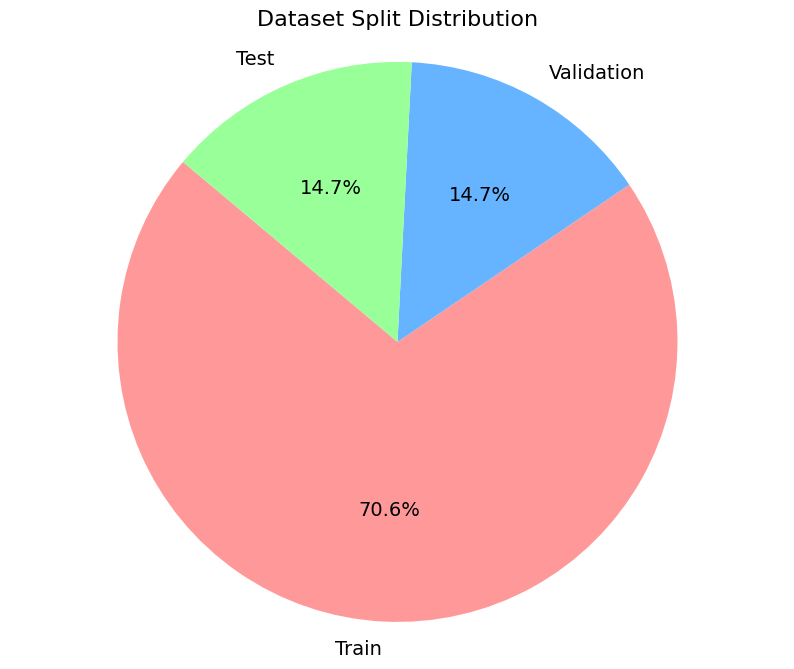

Total training shape: (30249, 224, 224, 3)
Total validation shape: (6300, 224, 224, 3)
Total test shape: (6299, 224, 224, 3)
Number of classes: 2

Process finished: Dataset split visualization and shape verification complete.


In [7]:
total_train = sum(data_counts['train'])
total_validation = sum(data_counts['validation'])
total_test = sum(data_counts['test'])

totals = [total_train, total_validation, total_test]
split_labels = ['Train', 'Validation', 'Test']
colors = ['#ff9999','#66b3ff','#99ff99']

plt.figure(figsize=(10, 8))
plt.pie(totals, labels=split_labels, autopct='%1.1f%%', startangle=140,
        colors=colors, textprops={'fontsize': 14})
plt.title('Dataset Split Distribution', fontsize=16)
plt.axis('equal')
plt.show()

print(f"Total training shape: ({total_train}, {IMG_HEIGHT}, {IMG_WIDTH}, 3)")
print(f"Total validation shape: ({total_validation}, {IMG_HEIGHT}, {IMG_WIDTH}, 3)")
print(f"Total test shape: ({total_test}, {IMG_HEIGHT}, {IMG_WIDTH}, 3)")
print(f"Number of classes: {len(class_names)}")
print("\nProcess finished: Dataset split visualization and shape verification complete.")

### Step 1.8: Checking for Class Balance ⚖️

A balanced dataset is crucial for training an unbiased model. This bar chart shows the exact number of images for each class in our training set, allowing us to quickly confirm that both categories are represented equally. This ensures our model won't favor one class over the other simply because it has more examples.

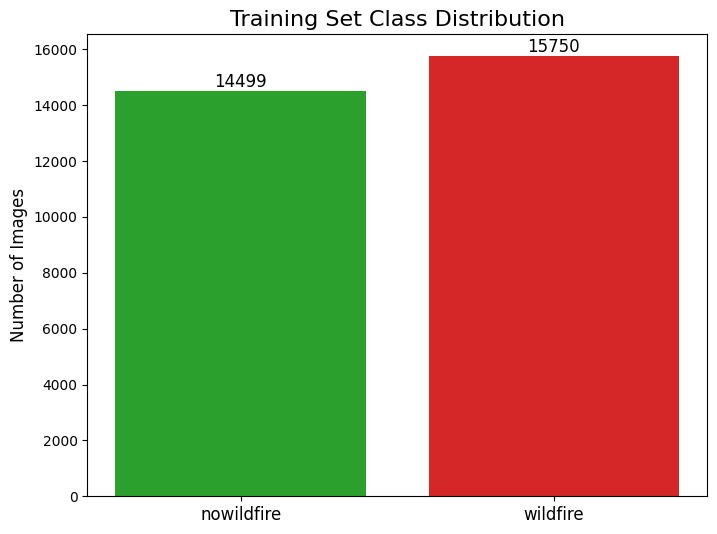

Process finished: Training set class distribution has been plotted.


In [8]:
plt.figure(figsize=(8, 6))
bars = plt.bar(class_names, data_counts['train'], color=['#2ca02c', '#d62728'])

plt.title('Training Set Class Distribution', fontsize=16)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center', fontsize=12)

plt.show()
print("Process finished: Training set class distribution has been plotted.")

### Step 1.9: A Glimpse at the Data 👀

Before we start training, let's take a look at the actual images we're working with. This cell displays a few random samples from both the `'No Wildfire'` and `'Wildfire'` categories. This is a quick and effective way to visually confirm that our labels are correct and to get an intuitive sense of the features our model will need to learn.

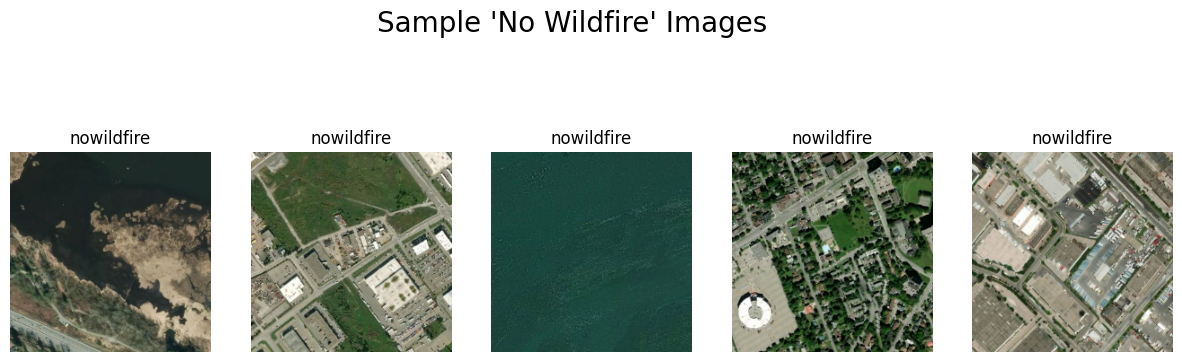

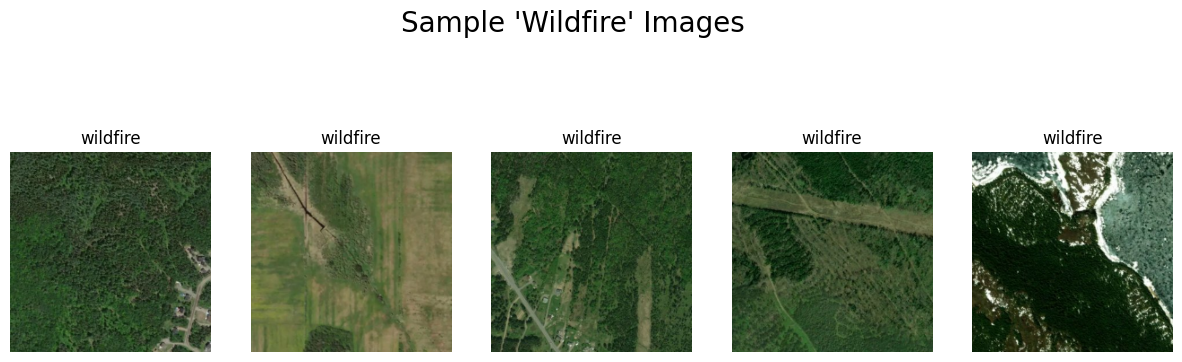

Process finished: Sample images for each class have been displayed.


In [9]:
train_ds_unbatched = train_ds.unbatch()

nowildfire_index = class_names.index('nowildfire')
wildfire_index = class_names.index('wildfire')

nowildfire_ds = train_ds_unbatched.filter(lambda image, label: tf.argmax(label) == nowildfire_index)
wildfire_ds = train_ds_unbatched.filter(lambda image, label: tf.argmax(label) == wildfire_index)

plt.figure(figsize=(15, 5))
plt.suptitle("Sample 'No Wildfire' Images", fontsize=20)
for i, (image, label) in enumerate(nowildfire_ds.take(5)):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(class_names[nowildfire_index])
    plt.axis("off")
plt.show()

plt.figure(figsize=(15, 5))
plt.suptitle("Sample 'Wildfire' Images", fontsize=20)
for i, (image, label) in enumerate(wildfire_ds.take(5)):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(class_names[wildfire_index])
    plt.axis("off")
plt.show()

print("Process finished: Sample images for each class have been displayed.")

## 2. Building the Model Architecture 🏗️

Now we define the blueprint for our Convolutional Neural Network (CNN). Instead of creating a single, static model, we'll define a flexible **hypermodel** using a function. This approach allows us to use the **Keras Tuner** library to automatically test different combinations of parameters and find the best possible version of our model.

Our model's architecture includes several key components:

-   **Data Augmentation**: To make our model more robust and prevent overfitting, we start with layers that randomly flip, rotate, zoom, and adjust the contrast/brightness of the input images.
-   **Convolutional Base**: This is the core of our CNN, consisting of stacked `Conv2D` and `MaxPooling2D` layers. These layers are responsible for learning and extracting features from the images. The number of filters is a **tunable hyperparameter**.
-   **Classifier Head**: After feature extraction, a `GlobalAveragePooling2D` layer reduces the data's dimensionality. This is followed by a `Dense` layer and a `Dropout` layer (both **tunable**) to make the final classification.
-   **Compilation**: Finally, the model is compiled with the `Adam` optimizer (with a **tunable learning rate**), the `categorical_crossentropy` loss function, and `accuracy` as our performance metric.

In [10]:
def build_model(hp):
    """
    Builds a tunable CNN model with data augmentation and hyperparameter search space.
    """
    data_augmentation = tf.keras.Sequential([
      layers.RandomFlip("horizontal_and_vertical"),
      layers.RandomRotation(0.2),
      layers.RandomZoom(0.2),
      layers.RandomContrast(0.2),
      layers.RandomBrightness(0.2)
    ], name="data_augmentation")

    model = tf.keras.Sequential()
    model.add(layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
    model.add(data_augmentation)
    model.add(layers.Rescaling(1./255))

    hp_filters = hp.Int('filters', min_value=16, max_value=64, step=16)
    model.add(layers.Conv2D(hp_filters, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Conv2D(hp_filters * 2, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Conv2D(hp_filters * 4, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.GlobalAveragePooling2D())

    hp_units = hp.Int('units', min_value=128, max_value=384, step=64)
    model.add(layers.Dense(units=hp_units, activation='relu'))

    hp_dropout = hp.Float('dropout', min_value=0.3, max_value=0.6, step=0.1)
    model.add(layers.Dropout(rate=hp_dropout))

    model.add(layers.Dense(num_classes, activation='softmax'))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("Process finished: Hypermodel build function defined successfully.")

Process finished: Hypermodel build function defined successfully.


## 3. Training the Final Model 🚀

This is the moment of truth. With our optimal parameters discovered, it's time to build and train our final model. This cell automates the entire process:

-   **Load Best Settings**: We start by loading the `best_hyperparameters.json` file, which contains the winning combination of filters, learning rate, and other settings from our tuning search.
-   **Build the Optimal Model**: Using these settings, we construct the model with the `build_model` function. A summary is printed to confirm its architecture.
-   **Add Safeguards**: We implement `EarlyStopping`, a smart callback that monitors the model's performance on the validation set. If the model stops improving for a few consecutive epochs, training will halt automatically to prevent overfitting and save the best version.
-   **Train and Save**: The `.fit()` command kicks off the training process. Once complete, the final, trained model is saved to a file, ready for evaluation and future use.

In [11]:
hps_path = "/kaggle/input/wildfire-classification-using-satellite-images-cnn/best_hyperparameters.json"
print(f"Loading best hyperparameters from: {hps_path}")

with open(hps_path, 'r') as f:
    hps_data = json.load(f)

best_hps = kt.HyperParameters()
best_hps.values = hps_data
print(f"-> Filters: {best_hps.get('filters')}, Units: {best_hps.get('units')}, Dropout: {best_hps.get('dropout'):.2f}, LR: {best_hps.get('learning_rate')}")

best_model = build_model(best_hps)
print("\\nModel built successfully with the best hyperparameters.")
best_model.summary()

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

EPOCHS = 50
print("\\n--- Starting Final Model Training ---")
history = best_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=[tensorboard_callback, early_stopping_callback]
)
print("--- Final Model Training Complete ---")

best_model.save('/kaggle/working/final_wildfire_model.keras')
print("Model saved to /kaggle/working/final_wildfire_model.keras")

Loading best hyperparameters from: /kaggle/input/wildfire-classification-using-satellite-images-cnn/best_hyperparameters.json
-> Filters: 64, Units: 384, Dropout: 0.40, LR: 0.001
\nModel built successfully with the best hyperparameters.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 384)            │        98,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 470,274 (1.79 MB)

 Trainable params: 470,274 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

\n--- Starting Final Model Training ---
Epoch 1/50


I0000 00:00:1758986470.102477      58 cuda_dnn.cc:529] Loaded cuDNN version 90300


946/946 ━━━━━━━━━━━━━━━━━━━━ 69s 65ms/step - accuracy: 0.8418 - loss: 0.3484 - val_accuracy: 0.9016 - val_loss: 0.2445
Epoch 2/50
946/946 ━━━━━━━━━━━━━━━━━━━━ 60s 63ms/step - accuracy: 0.9107 - loss: 0.2308 - val_accuracy: 0.9368 - val_loss: 0.1500
Epoch 3/50
946/946 ━━━━━━━━━━━━━━━━━━━━ 60s 63ms/step - accuracy: 0.9263 - loss: 0.1948 - val_accuracy: 0.9494 - val_loss: 0.1331
Epoch 4/50
946/946 ━━━━━━━━━━━━━━━━━━━━ 60s 63ms/step - accuracy: 0.9355 - loss: 0.1714 - val_accuracy: 0.9356 - val_loss: 0.1703
Epoch 5/50
946/946 ━━━━━━━━━━━━━━━━━━━━ 60s 63ms/step - accuracy: 0.9342 - loss: 0.1729 - val_accuracy: 0.9567 - val_loss: 0.1213
Epoch 6/50
946/946 ━━━━━━━━━━━━━━━━━━━━ 60s 63ms/step - accuracy: 0.9406 - loss: 0.1563 - val_accuracy: 0.9581 - val_loss: 0.1137
Epoch 7/50
946/946 ━━━━━━━━━━━━━━━━━━━━ 60s 63ms/step - accuracy: 0.9440 - loss: 0.1481 - val_accuracy: 0.9562 - val_loss: 0.1157
Epoch 8/50
946/946 ━━━━━━━━━━━━━━━━━━━━ 60s 63ms/step - accuracy: 0.9466 - loss: 0.1404 - val_accurac

## 4. Results and Analysis 📈

With the model training complete, it's time to evaluate its performance. A high final accuracy is great, but understanding *how* the model learned is even more important.

### Step 4.1: Visualizing the Learning Process

This cell plots the model's **accuracy** and **loss** for both the training and validation sets over each epoch. These graphs are crucial for diagnosing the health of our training process:

-   **Accuracy Plot**: Shows how well the model is learning to classify images correctly. We want to see both training and validation accuracy increasing and converging.
-   **Loss Plot**: Represents the model's error. A healthy training process will show both lines decreasing steadily.

These plots also help us confirm that `EarlyStopping` worked correctly, halting the training at the optimal point before the model started to overfit.

### Step 4.2: The Final Verdict

Finally, we evaluate our trained model on the **unseen test set**. This provides the most honest and reliable measure of its real-world performance, giving us the final **Test Accuracy** and **Test Loss**.

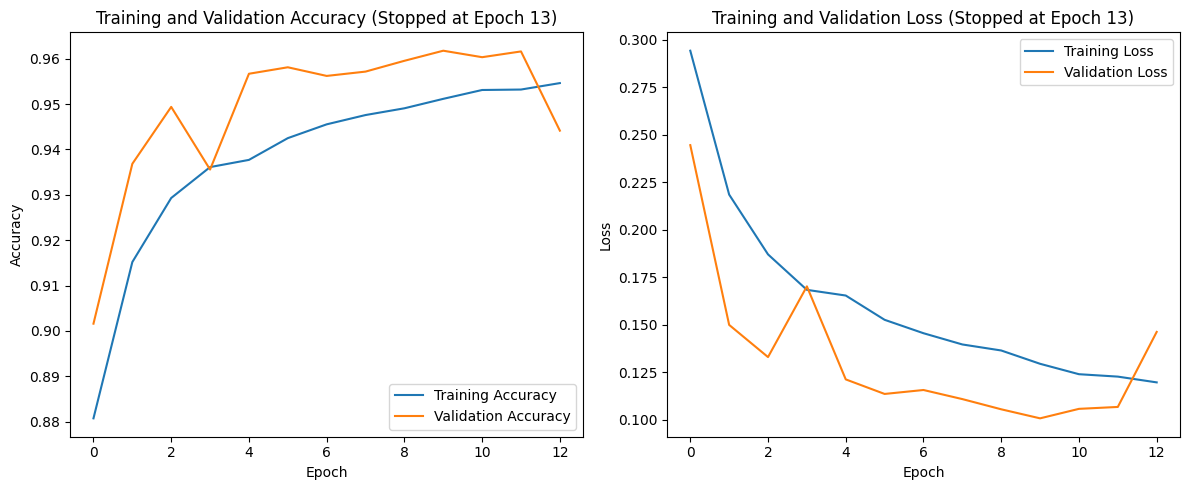


--- Evaluating on Test Data ---
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9710 - loss: 0.0761
Test Accuracy: 0.9702
Test Loss: 0.0784


In [12]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

actual_epochs = len(acc)
epochs_range = range(actual_epochs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title(f'Training and Validation Accuracy (Stopped at Epoch {actual_epochs})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title(f'Training and Validation Loss (Stopped at Epoch {actual_epochs})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

print("\n--- Evaluating on Test Data ---")
test_loss, test_accuracy = best_model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

##  Finding the Best Model: Hyperparameter Tuning 🧠

A great model architecture is just the start. To unlock its full potential, we need to find the best possible settings, or **hyperparameters**. Manually testing every combination of learning rates, filter counts, and dropout values would take forever. This is where **Keras Tuner** comes in.

### Step (Optional): Running the Keras Tuner Search

The code block below sets up and runs the hyperparameter search using the `Hyperband` algorithm. This process automatically trains and evaluates dozens of different model variations to find the combination that results in the highest validation accuracy.

**Note**: This search is computationally expensive and has already been run. The best results were saved to a file and will be loaded in the next step to train our final model. Therefore, this cell is commented out and does not need to be executed again.

In [13]:
'''
# --- THIS BLOCK IS COMMENTED OUT ---
tuner = kt.Hyperband(
    hypermodel=build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='keras_tuner_dir',
    project_name='wildfire_classification_hyperband'
)

tuner.search_space_summary()
print("\nProcess finished: Hyperband tuner initialized.")
'''

'\n# --- THIS BLOCK IS COMMENTED OUT ---\ntuner = kt.Hyperband(\n    hypermodel=build_model,\n    objective=\'val_accuracy\',\n    max_epochs=10,\n    factor=3,\n    directory=\'keras_tuner_dir\',\n    project_name=\'wildfire_classification_hyperband\'\n)\n\ntuner.search_space_summary()\nprint("\nProcess finished: Hyperband tuner initialized.")\n'

Once the tuner is initialized, the `.search()` method kicks off the automated tuning process. After the search is complete, we retrieve the best performing set of hyperparameters and save them to a `.json` file. This allows us to easily load the optimal configuration later without having to re-run the entire search. The best results from our run are then printed for review.

In [14]:
'''
# --- THIS BLOCK IS COMMENTED OUT ---
print("Starting hyperparameter search...")
#tuner.search(train_ds, 
#             validation_data=validation_ds,
#             callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)])
print("Hyperparameter search complete.")

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

hps_path = "/kaggle/working/best_hyperparameters.json"
with open(hps_path, 'w') as f:
    json.dump(best_hps.values, f)

print(f"En iyi HPO sonuçları {hps_path} dosyasına kaydedildi.")
print(f"""
Search is complete.
Best number of filters: {best_hps.get('filters')}
Best number of units in dense layer: {best_hps.get('units')}
Best dropout rate: {best_hps.get('dropout')}
Best learning rate: {best_hps.get('learning_rate')}
""")
'''

'\n# --- THIS BLOCK IS COMMENTED OUT ---\nprint("Starting hyperparameter search...")\n#tuner.search(train_ds, \n#             validation_data=validation_ds,\n#             callbacks=[tf.keras.callbacks.EarlyStopping(monitor=\'val_loss\', patience=3)])\nprint("Hyperparameter search complete.")\n\nbest_hps = tuner.get_best_hyperparameters(num_trials=1)[0]\n\nhps_path = "/kaggle/working/best_hyperparameters.json"\nwith open(hps_path, \'w\') as f:\n    json.dump(best_hps.values, f)\n\nprint(f"En iyi HPO sonuçları {hps_path} dosyasına kaydedildi.")\nprint(f"""\nSearch is complete.\nBest number of filters: {best_hps.get(\'filters\')}\nBest number of units in dense layer: {best_hps.get(\'units\')}\nBest dropout rate: {best_hps.get(\'dropout\')}\nBest learning rate: {best_hps.get(\'learning_rate\')}\n""")\n'

Finally, this last block demonstrates how you would take the `best_hps`, build the final model with those optimal settings, and train it.

---
*This entire hyperparameter tuning step was run to find the optimal model configuration. The results were saved to `best_hyperparameters.json` and are loaded in the main workflow to train the final model. You do not need to run these optional cells again.*

In [15]:
'''
# --- THIS BLOCK IS COMMENTED OUT ---
model = tuner.hypermodel.build(best_hps)
model.summary()

log_dir = "logs/best_model/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=[tensorboard_callback]
)

print("\nTraining of the best model is complete.")
print(f"TensorBoard logs are saved to the directory: {log_dir}")
'''

'''
This step was run to find the optimal hyperparameters. 
The results were saved to best_hyperparameters.json and are loaded in the next cell. 
You do not need to run this cell again unless you want to re-run the hyperparameter search.
'''

'\nThis step was run to find the optimal hyperparameters. \nThe results were saved to best_hyperparameters.json and are loaded in the next cell. \nYou do not need to run this cell again unless you want to re-run the hyperparameter search.\n'

## 5. A Deeper Dive into Performance 🧐

Overall accuracy tells us the big picture, but to truly trust our model, we need to dig deeper. This final analysis gives us a detailed breakdown of its performance on the unseen test data.

### Step 5.1: Classification Report

The **Classification Report** is like a detailed report card for our model. It goes beyond simple accuracy to show us key metrics for each class:

-   **Precision**: Of all the times the model predicted "Fire," how many were actually correct?
-   **Recall**: Of all the actual "Fire" images, how many did the model successfully find?
-   **F1-Score**: A balanced average of Precision and Recall.

This helps us see if the model is biased or if it struggles with one class more than the other.

### Step 5.2: The Confusion Matrix

The **Confusion Matrix** is a simple but powerful visual tool. It gives us a direct comparison of the model's predictions versus the actual labels, showing us exactly where it's getting things right and where it's getting confused. It's the clearest way to see how many images were correctly classified and, more importantly, how many were misclassified.

Classes found: ['nowildfire', 'wildfire']

--- Classification Report ---
              precision    recall  f1-score   support

  nowildfire       0.97      0.96      0.97      2820
    wildfire       0.97      0.98      0.97      3479

    accuracy                           0.97      6299
   macro avg       0.97      0.97      0.97      6299
weighted avg       0.97      0.97      0.97      6299


--- Confusion Matrix ---


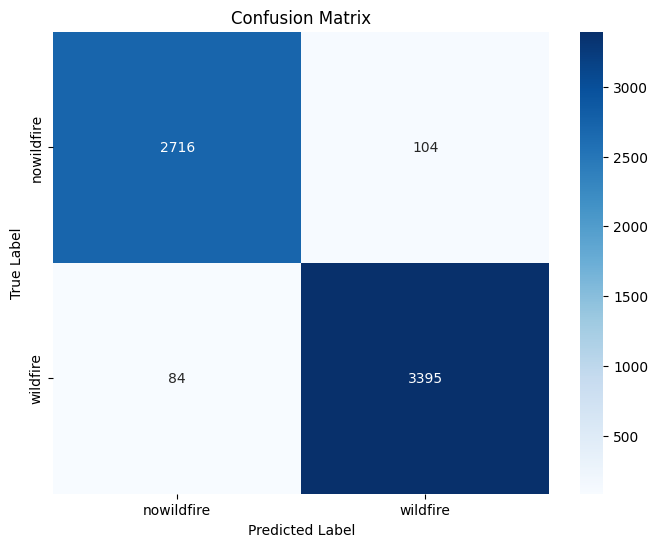

In [16]:
# Create empty lists to store the model's predictions and the true labels
y_pred = []
y_true = []

# Iterate over the test dataset (test_ds) to make predictions for all images
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    # Add the index of the true labels to the list
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Get class names from the training directory for consistent labeling
train_dir = os.path.join(cleaned_data_dir, 'train')
class_names = sorted(os.listdir(train_dir))
print(f"Classes found: {class_names}")

# --- Generate and Print Classification Report ---
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# --- Generate and Visualize Confusion Matrix ---
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

## 6. Peeking Inside the Black Box: Model Interpretability with Grad-CAM 🧠

Our model can predict wildfires with high accuracy, but *how* does it actually make its decisions? Is it looking at the smoke, the color of the flames, or something else entirely? To answer this, we'll use a powerful technique called **Grad-CAM (Gradient-weighted Class Activation Mapping)**.

Grad-CAM creates a **heatmap** that highlights the specific regions in an image that were most influential for the model's prediction. This helps us understand and trust our model's "thought process."

The process involves:
1.  **Rebuilding the Model**: We reconstruct our trained model using the Keras Functional API, which makes it easier to access its internal layers.
2.  **Loading the Weights**: We load the weights from our best-trained model to ensure we're analyzing the exact same "brain."
3.  **Generating the Heatmap**: For a sample image, the Grad-CAM algorithm identifies which pixels the final convolutional layer focused on to make its decision.
4.  **Visualizing the Result**: We overlay this heatmap on the original image, giving us a clear and intuitive look at what the model "sees."

Creating a clean Functional API model for Grad-CAM analysis...
Functional model created and weights loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


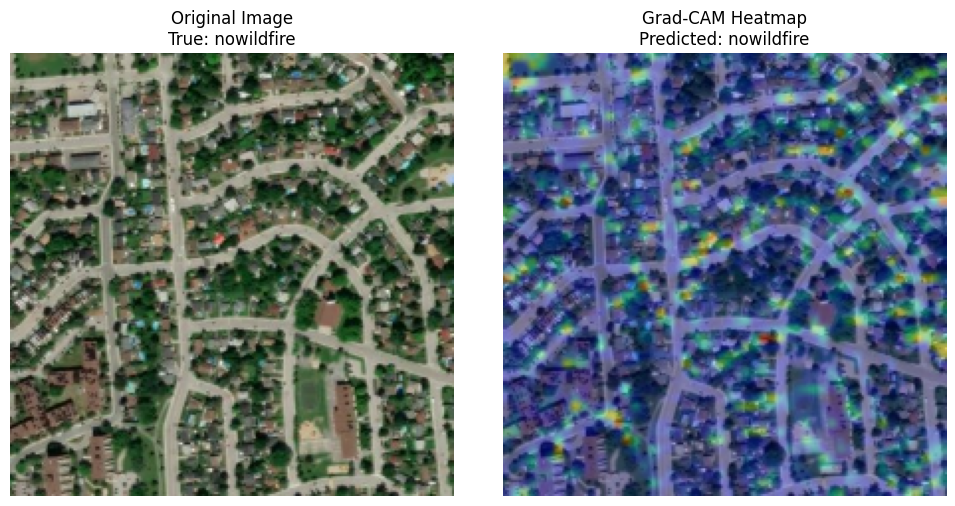

In [17]:
# --- 1. Recreate Model with Functional API for Grad-CAM ---
print("Creating a clean Functional API model for Grad-CAM analysis...")

# Define the input layer
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="input_layer")

# Replicate the architecture of the trained model using the Functional API
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2)
], name="data_augmentation")(inputs)

x = layers.Rescaling(1./255, name="rescaling")(data_augmentation)
x = layers.Conv2D(best_hps.get('filters'), (3, 3), activation='relu', name="conv1")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="pool1")(x)
x = layers.Conv2D(best_hps.get('filters') * 2, (3, 3), activation='relu', name="conv2")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="pool2")(x)
# Assign a specific name to the last convolutional layer for easy access
x = layers.Conv2D(best_hps.get('filters') * 4, (3, 3), activation='relu', name="last_conv_layer")(x)
x = layers.GlobalAveragePooling2D(name="global_pool")(x)
x = layers.Dense(units=best_hps.get('units'), activation='relu', name="dense_layer")(x)
x = layers.Dropout(rate=best_hps.get('dropout'), name="dropout")(x)
outputs = layers.Dense(num_classes, activation='softmax', name="output_layer")(x)

# Create the final functional model
functional_model = tf.keras.Model(inputs, outputs)

# --- 2. Load Weights from the Previously Trained Model ---
functional_model.set_weights(best_model.get_weights())
print("Functional model created and weights loaded successfully.")


# --- 3. Grad-CAM Helper Functions ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Create a model that maps the input image to the activations of the last conv layer and the output predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    # Use GradientTape to compute the gradient of the top predicted class with respect to the output feature map
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    # Average the gradients along the spatial dimensions
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    # Multiply each channel in the feature map array by "how important this channel is"
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    # Normalize the heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-7)
    return heatmap.numpy()

def save_and_display_gradcam(img, heatmap, alpha=0.5):
    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)
    # Use jet colormap to colorize heatmap
    jet = plt.colormaps.get_cmap("jet") 
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)
    return superimposed_img


# --- 4. Perform and Visualize Grad-CAM ---
# Get a sample image from the test dataset
image_batch, label_batch = next(iter(test_ds.take(1)))
sample_image = image_batch[0]
img_array = tf.expand_dims(sample_image, 0)

# Generate heatmap for the sample image
heatmap = make_gradcam_heatmap(img_array, functional_model, "last_conv_layer")

# Display the original image and the superimposed heatmap
actual_class_name = class_names[np.argmax(label_batch[0])]
predicted_class_name = class_names[np.argmax(functional_model.predict(img_array))]
superimposed_img = save_and_display_gradcam(sample_image.numpy(), heatmap)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_image.numpy().astype("uint8"))
plt.title(f"Original Image\nTrue: {actual_class_name}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title(f"Grad-CAM Heatmap\nPredicted: {predicted_class_name}")
plt.axis("off")

plt.tight_layout()
plt.show()